# 우리지역 인구와 연령대별 인구 분포 알아보기 

- 인구 분포를 다양한 각도로 시각화 살펴보고, 이를 통해 행정적
인사이트 찾고 문제 정의하기

- 구청 직원분께 행정정책을 제안한다면 어떻게 할 것인지?
    - 각 동명과 인구를 지도에 표시하기
    - folium또는 다른 지도를 사용해도 됨
    - 사용자가 편하게 마우스를 올리면 툴팁이 표시되도록 하기

문제정의 > 데이터 수집 > 데이터 이해 > 데이터 전처리 > EDA 

분석검증 > 모델링 > 해석 의사결정 

## 문제정의

평택시는 최근 10년간(2016.07~2026.07) 전체 인구가 꾸준히 증가해왔다. 하지만 이 증가는 시 전체에 고르게 나타난 것이 아니라,
**동별로 극명하게 엇갈리는 두 가지 흐름이 공존**하는 형태로 나타난다: 택지개발이 진행 중인 신도심(고덕동, 동삭동, 세교동 등)은
인구가 급증하는 반면, 원도심과 면 지역(서탄면, 오성면, 신장2동 등)은 인구가 감소하며 동시에 고령화가 심화되고 있다.

이 양극화를 방치하면, 한쪽에서는 보육·교육 인프라 부족으로 대기 수요가 쌓이고, 다른 한쪽에서는 돌봄 공백과 지역 활력 저하가
동시에 심화될 위험이 있다. 이 프로젝트는 다음 질문에 답하는 것을 목표로 한다.

1. 평택시 내에서 인구 증가/감소와 고령화는 실제로 공간적으로 어떻게 분포하는가?
2. 인구 감소 지역에서 인구감소를 해결하는 방법은? 

이 질문에 답하기 위해 ① 10년치 동별 인구 데이터, ② 2026년 상반기 연령대별 인구 데이터, ③ 평택시·경기도·정부의 실제 정책 자료를
함께 분석한다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# 10년 데이터 ./datas_3/201607_201706_주민등록인구및세대현황_월간.csv',encoding='cp949')
from functools import reduce

# 1. 반드시 같은 인코딩으로 읽기
pop_2016_2017 = pd.read_csv('./datas_3/201607_201706_주민등록인구및세대현황_월간.csv', encoding='cp949')
pop_2017_2022 = pd.read_csv('./datas_3/201707_202206_주민등록인구및세대현황_월간.csv', encoding='cp949')
pop_2022_2026 = pd.read_csv('./datas_3/202207_202607_주민등록인구및세대현황_월간.csv', encoding='cp949')

print(pop_2016_2017.columns[:3].tolist())
print(pop_2017_2022.columns[:3].tolist())
print(pop_2022_2026.columns[:3].tolist())

# # 2. concat(세로쌓기) ❌ → merge(가로결합, 행정구역 기준) ✅
pop_2016_2026 = reduce(
    lambda left, right: pd.merge(left, right, on='행정구역', how='outer'),
    [pop_2016_2017, pop_2017_2022, pop_2022_2026]
)

print(pop_2016_2026.shape)   # (26, 727) 나와야 정상
print(pop_2016_2026['행정구역'].isnull().sum())  # 0 나와야 정상

['행정구역', '2016년07월_총인구수', '2016년07월_세대수']
['행정구역', '2017년07월_총인구수', '2017년07월_세대수']
['행정구역', '2022년07월_총인구수', '2022년07월_세대수']
(26, 727)
0


In [4]:
import os

data_path = "datas_3/pop_10.csv"

# os.makedirs("cleaning_data", exist_ok=True)

pop_2016_2026.to_csv(
    data_path,
    index=False,
    encoding='cp949'
)

## 데이터 이해 및 전처리


In [5]:
pop_2016_2026 = pd.read_csv('./datas_3/pop_10.csv',encoding='cp949')

pop_2016_2026.head(5)

,행정구역,2016년07월_총인구수,2016년07월_세대수,2016년07월_세대당 인구,2016년07월_남자 인구수,2016년07월_여자 인구수,2016년07월_남여 비율,2016년08월_총인구수,2016년08월_세대수,2016년08월_세대당 인구,...,2026년06월_세대당 인구,2026년06월_남자 인구수,2026년06월_여자 인구수,2026년06월_남여 비율,2026년07월_총인구수,2026년07월_세대수,2026년07월_세대당 인구,2026년07월_남자 인구수,2026년07월_여자 인구수,2026년07월_남여 비율
0,경기도 평택시 (4122000000),"466,327","192,778",2.42,"237,727","228,600",1.04,"467,255","193,383",2.42,...,2.07,"325,937","293,733",1.11,"620,754","300,057",2.07,"326,607","294,147",1.11
1,경기도 평택시 고덕동(4122066000),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.26,"35,146","31,181",1.13,"66,446","29,391",2.26,"35,203","31,243",1.13
2,경기도 평택시 고덕면(4122033000),"11,870","4,631",2.56,"6,176","5,694",1.08,"11,811","4,606",2.56,...,1.93,"7,052","5,760",1.22,"12,771","6,651",1.92,"7,043","5,728",1.23
3,경기도 평택시 동삭동(4122065000),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.27,"22,735","20,653",1.10,"43,468","19,076",2.28,"22,800","20,668",1.10
4,경기도 평택시 비전1동(4122062000),"43,137","17,448",2.47,"21,763","21,374",1.02,"44,270","17,812",2.49,...,2.25,"25,211","25,195",1.00,"50,428","22,451",2.25,"25,229","25,199",1.00


In [6]:
# 행정구역 목록 및 결측 확인 (NaN)
pop_2016_2026['행정구역'].isnull().sum()
pop_2016_2026['행정구역'].tolist()

['경기도 평택시 (4122000000)',
 '경기도 평택시 고덕동(4122066000)',
 '경기도 평택시 고덕면(4122033000)',
 '경기도 평택시 동삭동(4122065000)',
 '경기도 평택시 비전1동(4122062000)',
 '경기도 평택시 비전2동(4122063000)',
 '경기도 평택시 서정동(4122052000)',
 '경기도 평택시 서탄면(4122032000)',
 '경기도 평택시 세교동(4122064000)',
 '경기도 평택시 송북동(4122056000)',
 '경기도 평택시 송탄동(4122053500)',
 '경기도 평택시 신장1동(4122057000)',
 '경기도 평택시 신장2동(4122058000)',
 '경기도 평택시 신평동(4122059000)',
 '경기도 평택시 안중읍(4122025300)',
 '경기도 평택시 오성면(4122034000)',
 '경기도 평택시 용이동(4122063500)',
 '경기도 평택시 원평동(4122060000)',
 '경기도 평택시 중앙동(4122051000)',
 '경기도 평택시 지산동(4122055000)',
 '경기도 평택시 진위면(4122031000)',
 '경기도 평택시 청북읍(4122025900)',
 '경기도 평택시 통복동(4122061000)',
 '경기도 평택시 팽성읍(4122025000)',
 '경기도 평택시 포승읍(4122025600)',
 '경기도 평택시 현덕면(4122037000)']

In [7]:
# 이름, 코드 분리

pop_2016_2026[['행정구역명', '행정구역코드']] = pop_2016_2026['행정구역'].str.extract(r'(.+?)\s*\((\d+)\)')

pop_2016_2026[['행정구역', '행정구역명', '행정구역코드']]

/tmp/ipykernel_33875/2105786426.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pop_2016_2026[['행정구역명', '행정구역코드']] = pop_2016_2026['행정구역'].str.extract(r'(.+?)\s*\((\d+)\)')


,행정구역,행정구역명,행정구역코드
0,경기도 평택시 (4122000000),경기도 평택시,4122000000
1,경기도 평택시 고덕동(4122066000),경기도 평택시 고덕동,4122066000
2,경기도 평택시 고덕면(4122033000),경기도 평택시 고덕면,4122033000
3,경기도 평택시 동삭동(4122065000),경기도 평택시 동삭동,4122065000
4,경기도 평택시 비전1동(4122062000),경기도 평택시 비전1동,4122062000
5,경기도 평택시 비전2동(4122063000),경기도 평택시 비전2동,4122063000
6,경기도 평택시 서정동(4122052000),경기도 평택시 서정동,4122052000
7,경기도 평택시 서탄면(4122032000),경기도 평택시 서탄면,4122032000
8,경기도 평택시 세교동(4122064000),경기도 평택시 세교동,4122064000
9,경기도 평택시 송북동(4122056000),경기도 평택시 송북동,4122056000


In [8]:
# 컬럼별 총인구수 결측 패턴 확인 (어떤 동이 비어있는지)
pop_cols = [c for c in pop_2016_2026.columns if '총인구수' in c]
na_summary = pop_2016_2026.set_index('행정구역')[pop_cols].isnull().sum(axis=1).sort_values(ascending=False)
na_summary

행정구역
경기도 평택시 고덕동(4122066000)     12
경기도 평택시 동삭동(4122065000)     12
경기도 평택시 용이동(4122063500)     12
경기도 평택시 (4122000000)         0
경기도 평택시 비전1동(4122062000)     0
경기도 평택시 고덕면(4122033000)      0
경기도 평택시 서정동(4122052000)      0
경기도 평택시 서탄면(4122032000)      0
경기도 평택시 세교동(4122064000)      0
경기도 평택시 비전2동(4122063000)     0
경기도 평택시 송북동(4122056000)      0
경기도 평택시 송탄동(4122053500)      0
경기도 평택시 신장2동(4122058000)     0
경기도 평택시 신장1동(4122057000)     0
경기도 평택시 신평동(4122059000)      0
경기도 평택시 안중읍(4122025300)      0
경기도 평택시 오성면(4122034000)      0
경기도 평택시 원평동(4122060000)      0
경기도 평택시 중앙동(4122051000)      0
경기도 평택시 지산동(4122055000)      0
경기도 평택시 진위면(4122031000)      0
경기도 평택시 청북읍(4122025900)      0
경기도 평택시 통복동(4122061000)      0
경기도 평택시 팽성읍(4122025000)      0
경기도 평택시 포승읍(4122025600)      0
경기도 평택시 현덕면(4122037000)      0
dtype: int64

In [9]:
# 신설동 3개 목록
# (선택) 신설동 정보를 별도로 기록해두기 - 나중에 EDA/보고서에서 참고용
new_dongs = ['경기도 평택시 고덕동(4122066000)', '경기도 평택시 동삭동(4122065000)', '경기도 평택시 용이동(4122063500)']

# 이 동들의 총인구수가 언제부터 값이 생기는지 확인
for dong in new_dongs:
    row = pop_2016_2026[pop_2016_2026['행정구역'] == dong]
    pop_cols = [c for c in pop_2016_2026.columns if '총인구수' in c]
    first_valid = row[pop_cols].notnull().idxmax(axis=1).values[0]
    print(f"{dong} → 첫 데이터 시작: {first_valid}")

경기도 평택시 고덕동(4122066000) → 첫 데이터 시작: 2017년07월_총인구수
경기도 평택시 동삭동(4122065000) → 첫 데이터 시작: 2017년07월_총인구수
경기도 평택시 용이동(4122063500) → 첫 데이터 시작: 2017년07월_총인구수


In [10]:
# 컬럼별 총인구수 결측 패턴 확인 (어떤 동이 몇 개월 비어있는지)
pop_cols = [c for c in pop_2016_2026.columns if '총인구수' in c]
na_summary = pop_2016_2026.set_index('행정구역')[pop_cols].isnull().sum(axis=1).sort_values(ascending=False)
na_summary

행정구역
경기도 평택시 고덕동(4122066000)     12
경기도 평택시 동삭동(4122065000)     12
경기도 평택시 용이동(4122063500)     12
경기도 평택시 (4122000000)         0
경기도 평택시 비전1동(4122062000)     0
경기도 평택시 고덕면(4122033000)      0
경기도 평택시 서정동(4122052000)      0
경기도 평택시 서탄면(4122032000)      0
경기도 평택시 세교동(4122064000)      0
경기도 평택시 비전2동(4122063000)     0
경기도 평택시 송북동(4122056000)      0
경기도 평택시 송탄동(4122053500)      0
경기도 평택시 신장2동(4122058000)     0
경기도 평택시 신장1동(4122057000)     0
경기도 평택시 신평동(4122059000)      0
경기도 평택시 안중읍(4122025300)      0
경기도 평택시 오성면(4122034000)      0
경기도 평택시 원평동(4122060000)      0
경기도 평택시 중앙동(4122051000)      0
경기도 평택시 지산동(4122055000)      0
경기도 평택시 진위면(4122031000)      0
경기도 평택시 청북읍(4122025900)      0
경기도 평택시 통복동(4122061000)      0
경기도 평택시 팽성읍(4122025000)      0
경기도 평택시 포승읍(4122025600)      0
경기도 평택시 현덕면(4122037000)      0
dtype: int64

In [11]:
# 숫자 컬럼 형식 확인 (콤마 포함 여부 등)
pop_2016_2026['2016년07월_총인구수'].head()

0    466,327
1        NaN
2     11,870
3        NaN
4     43,137
Name: 2016년07월_총인구수, dtype: str

In [12]:
# 콤마 제거 후 숫자형 변환

numeric_target_cols = [col for col in pop_2016_2026.columns 
                        if any(k in col for k in ['총인구수', '세대수', '남자 인구수', '여자 인구수'])]

for col in numeric_target_cols:
    pop_2016_2026[col] = (
        pop_2016_2026[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('nan', pd.NA)
    )
    pop_2016_2026[col] = pd.to_numeric(pop_2016_2026[col], errors='coerce')


    

In [13]:
pop_2016_2026[numeric_target_cols].dtypes.head()

2016년07월_총인구수      float64
2016년07월_세대수       float64
2016년07월_남자 인구수    float64
2016년07월_여자 인구수    float64
2016년08월_총인구수      float64
dtype: object

In [14]:
# 값이 콤마 없이 숫자로 잘 바뀌었는지 확인
pop_2016_2026['2016년07월_총인구수'].head()

0    466327.0
1         NaN
2     11870.0
3         NaN
4     43137.0
Name: 2016년07월_총인구수, dtype: float64

In [15]:
# 행정구역코드가 4122000000(뒤 6자리 전부 0)인 행이 평택시 전체 합계였습니다. 개별 동과 섞어서 합산하면 인구가 중복 집계되니 분리해둡니다.

# 시 전체 합계 (평택시 전체 추이 분석용)
pop_city_total = pop_2016_2026[pop_2016_2026['행정구역코드'].str.endswith('000000')].copy()

# 개별 동만 (동별 비교, 지도 시각화용)
pop_dong_only = pop_2016_2026[~pop_2016_2026['행정구역코드'].str.endswith('000000')].copy()

In [16]:
print(pop_city_total.shape)
print(pop_dong_only.shape)

(1, 729)
(25, 729)


In [17]:
pop_city_total[['행정구역', '행정구역명', '행정구역코드']]

,행정구역,행정구역명,행정구역코드
0,경기도 평택시 (4122000000),경기도 평택시,4122000000


In [18]:
pop_dong_only[['행정구역', '행정구역명', '행정구역코드']]

,행정구역,행정구역명,행정구역코드
1,경기도 평택시 고덕동(4122066000),경기도 평택시 고덕동,4122066000
2,경기도 평택시 고덕면(4122033000),경기도 평택시 고덕면,4122033000
3,경기도 평택시 동삭동(4122065000),경기도 평택시 동삭동,4122065000
4,경기도 평택시 비전1동(4122062000),경기도 평택시 비전1동,4122062000
5,경기도 평택시 비전2동(4122063000),경기도 평택시 비전2동,4122063000
6,경기도 평택시 서정동(4122052000),경기도 평택시 서정동,4122052000
7,경기도 평택시 서탄면(4122032000),경기도 평택시 서탄면,4122032000
8,경기도 평택시 세교동(4122064000),경기도 평택시 세교동,4122064000
9,경기도 평택시 송북동(4122056000),경기도 평택시 송북동,4122056000
10,경기도 평택시 송탄동(4122053500),경기도 평택시 송탄동,4122053500


## 연령대별 인구 데이터 전처리

- `pop_10.csv`(10년치)에는 연령 구간 정보가 없어서, 별도 파일(`202601_202606_연령별인구현황_월간.csv`)을 사용합니다.
- 이 파일은 2026년 01월~06월(6개월치)만 있으므로, 10년 추이가 아니라 **최신 시점의 동별 연령 구조**를 보는 용도로 사용합니다.
- 컬럼 구조: `연월_성별(계/남/여)_지표` → 여기서는 '계' 기준, 최신월(2026년06월)만 사용합니다.

In [19]:
# 연령별 인구 파일 불러오기
age_2026 = pd.read_csv('./datas_3/202601_202606_연령별인구현황_월간.csv', encoding='cp949')

age_2026.shape

(26, 235)

In [20]:
# 행정구역명 / 행정구역코드 분리 (pop_10.csv와 동일한 방식)
age_2026[['행정구역명', '행정구역코드']] = age_2026['행정구역'].str.extract(r'(.+?)\s*\((\d+)\)')

age_2026[['행정구역', '행정구역명', '행정구역코드']]

,행정구역,행정구역명,행정구역코드
0,경기도 평택시 (4122000000),경기도 평택시,4122000000
1,경기도 평택시 팽성읍(4122025000),경기도 평택시 팽성읍,4122025000
2,경기도 평택시 안중읍(4122025300),경기도 평택시 안중읍,4122025300
3,경기도 평택시 포승읍(4122025600),경기도 평택시 포승읍,4122025600
4,경기도 평택시 청북읍(4122025900),경기도 평택시 청북읍,4122025900
5,경기도 평택시 진위면(4122031000),경기도 평택시 진위면,4122031000
6,경기도 평택시 서탄면(4122032000),경기도 평택시 서탄면,4122032000
7,경기도 평택시 고덕면(4122033000),경기도 평택시 고덕면,4122033000
8,경기도 평택시 오성면(4122034000),경기도 평택시 오성면,4122034000
9,경기도 평택시 현덕면(4122037000),경기도 평택시 현덕면,4122037000


In [21]:
# 최신월(2026년06월) '계' 기준 컬럼만 추출

age_bands = ['0~9세','10~19세','20~29세','30~39세','40~49세',
             '50~59세','60~69세','70~79세','80~89세','90~99세','100세 이상']

target_cols = ['2026년06월_계_총인구수'] + [f'2026년06월_계_{b}' for b in age_bands]

age_latest = age_2026[['행정구역명', '행정구역코드'] + target_cols].copy()
age_latest.head()

,행정구역명,행정구역코드,2026년06월_계_총인구수,2026년06월_계_0~9세,2026년06월_계_10~19세,2026년06월_계_20~29세,2026년06월_계_30~39세,2026년06월_계_40~49세,2026년06월_계_50~59세,2026년06월_계_60~69세,2026년06월_계_70~79세,2026년06월_계_80~89세,2026년06월_계_90~99세,2026년06월_계_100세 이상
0,경기도 평택시,4122000000,"619,670","46,290","59,337","72,154","101,733","101,939","102,985","77,445","37,152","17,499","3,069",67
1,경기도 평택시 팽성읍,4122025000,"26,999","1,129","1,752","2,411","2,963","3,486","4,938","5,130","3,134","1,733",316,7
2,경기도 평택시 안중읍,4122025300,"40,712","1,973","4,661","4,974","4,742","6,440","8,423","5,363","2,586","1,309",235,6
3,경기도 평택시 포승읍,4122025600,"21,171",785,"1,384","2,519","3,124","3,481","4,157","3,291","1,535",740,153,2
4,경기도 평택시 청북읍,4122025900,"25,892","2,052","3,816","2,223","3,266","5,584","3,995","2,714","1,458",658,123,3


In [22]:
# 콤마 제거 후 숫자형 변환

for col in target_cols:
    age_latest[col] = (
        age_latest[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('nan', pd.NA)
    )
    age_latest[col] = pd.to_numeric(age_latest[col], errors='coerce')

# 컬럼명 정리
age_latest.columns = ['행정구역명', '행정구역코드', '총인구수'] + age_bands
age_latest.head()

,행정구역명,행정구역코드,총인구수,0~9세,10~19세,20~29세,30~39세,40~49세,50~59세,60~69세,70~79세,80~89세,90~99세,100세 이상
0,경기도 평택시,4122000000,619670,46290,59337,72154,101733,101939,102985,77445,37152,17499,3069,67
1,경기도 평택시 팽성읍,4122025000,26999,1129,1752,2411,2963,3486,4938,5130,3134,1733,316,7
2,경기도 평택시 안중읍,4122025300,40712,1973,4661,4974,4742,6440,8423,5363,2586,1309,235,6
3,경기도 평택시 포승읍,4122025600,21171,785,1384,2519,3124,3481,4157,3291,1535,740,153,2
4,경기도 평택시 청북읍,4122025900,25892,2052,3816,2223,3266,5584,3995,2714,1458,658,123,3


In [23]:
# 유소년 / 고령 인구 비율 계산
# - 유소년: 0~9세 (실제 유소년 기준은 0~14세지만, 연령 구간이 10세 단위라 0~9세로 근사)
# - 고령: 70세 이상 전부 + 60~69세의 절반 (65세 이상을 10세 단위 구간으로 근사)

age_latest['유소년인구(0~9세)'] = age_latest['0~9세']
age_latest['고령인구(65세+)_근사'] = (
    age_latest['70~79세'] + age_latest['80~89세'] +
    age_latest['90~99세'] + age_latest['100세 이상'] +
    age_latest['60~69세'] * 0.5
)

age_latest['유소년비율(%)'] = (age_latest['유소년인구(0~9세)'] / age_latest['총인구수'] * 100).round(1)
age_latest['고령인구비율(%)'] = (age_latest['고령인구(65세+)_근사'] / age_latest['총인구수'] * 100).round(1)

age_latest[['행정구역명', '총인구수', '유소년비율(%)', '고령인구비율(%)']].sort_values('고령인구비율(%)', ascending=False)

,행정구역명,총인구수,유소년비율(%),고령인구비율(%)
6,경기도 평택시 서탄면,3300,2.3,37.4
8,경기도 평택시 오성면,5987,2.4,34.5
16,경기도 평택시 신장2동,4581,1.9,30.9
1,경기도 평택시 팽성읍,26999,4.2,28.7
5,경기도 평택시 진위면,10639,2.3,28.5
14,경기도 평택시 송북동,20334,4.3,22.1
17,경기도 평택시 신평동,19418,2.7,22.0
11,경기도 평택시 서정동,24537,3.8,21.3
18,경기도 평택시 원평동,12627,4.7,21.0
7,경기도 평택시 고덕면,12812,5.6,20.5


In [24]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


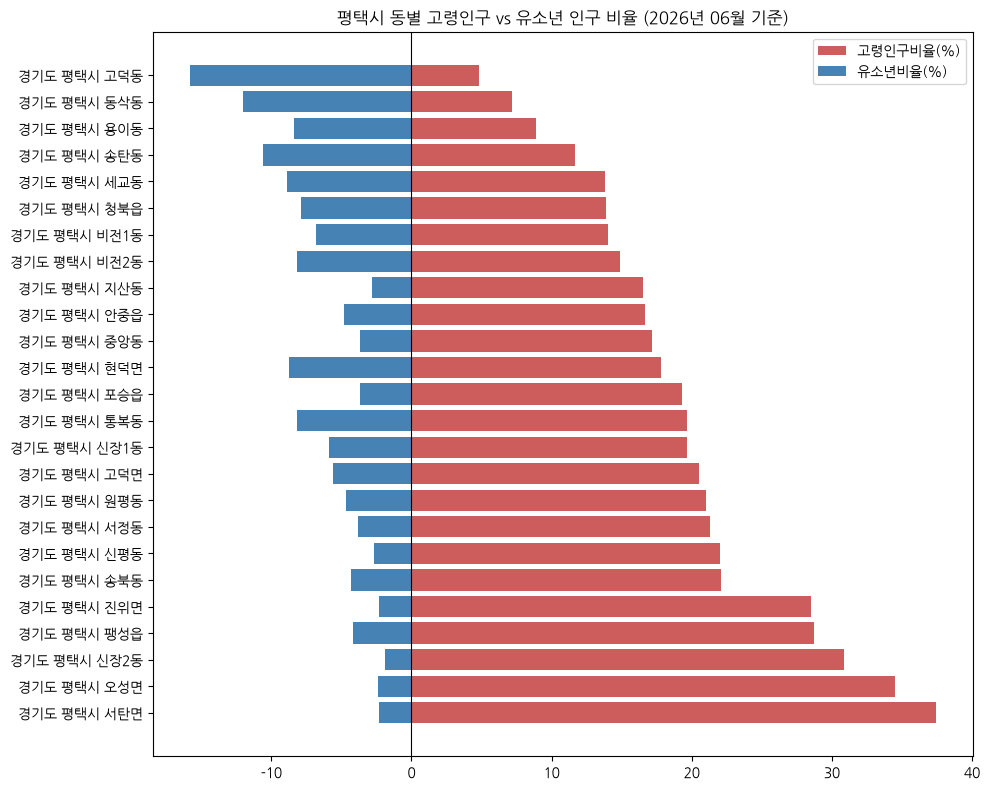

In [25]:
# 시각화: 동별 고령인구비율 vs 유소년비율 비교 (평택시 전체 행 제외)

age_dong = age_latest[age_latest['행정구역코드'] != '4122000000'].sort_values('고령인구비율(%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(age_dong))
ax.barh(y, age_dong['고령인구비율(%)'], color='indianred', label='고령인구비율(%)')
ax.barh(y, -age_dong['유소년비율(%)'], color='steelblue', label='유소년비율(%)')
ax.set_yticks(y)
ax.set_yticklabels(age_dong['행정구역명'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('평택시 동별 고령인구 vs 유소년 인구 비율 (2026년 06월 기준)')
ax.legend()
plt.tight_layout()
plt.show()

### 연령 구조 분석 인사이트 메모

- **서탄면, 오성면, 신장2동, 팽성읍, 진위면**: 고령인구비율 28~37%로 매우 높음 → 노인복지시설, 방문의료, 교통약자 이동지원 등 고령친화 정책 우선 검토 필요
- **고덕동, 동삭동, 용이동**: 신설 택지지구로 유소년비율이 높고(12~16%) 고령비율은 한 자릿수 → 어린이집·초등학교·놀이시설 등 보육/교육 인프라 수요가 빠르게 증가할 가능성
- 다음 단계에서 이 연령 구조 데이터를 `pop_dong_only`(10년치 인구 데이터)와 함께 지도에 표시하면, 단순 인구수뿐 아니라 '어떤 동이 고령화/저출산 정책이 시급한지'까지 한눈에 보여줄 수 있음

## 지도 시각화: 동별 위경도 가져오기 + folium 지도

- 위경도는 `geopy`의 `Nominatim`으로 지오코딩합니다 (8-2 실습 방식과 동일)
- 요청이 너무 빠르면 차단될 수 있으므로 `time.sleep(1)`로 간격을 둡니다
- 매번 다시 지오코딩하지 않도록 결과를 CSV로 저장해두고, 이후에는 저장된 파일을 재사용합니다

In [26]:
# uv add geopy folium

In [27]:
from geopy.geocoders import Nominatim
import time
import os

geolocator = Nominatim(user_agent="pyeongtaek-pop-map")  # user_agent는 본인만의 고유한 이름으로 지정

coords_path = 'datas_3/dong_coords.csv'

# 이미 지오코딩해둔 결과가 있으면 재사용 (Nominatim 반복 호출 방지)
if os.path.exists(coords_path):
    dong_coords = pd.read_csv(coords_path)
else:
    dong_names = pop_dong_only['행정구역명'].tolist()
    
    lats, lons = [], []
    for name in dong_names:
        try:
            location = geolocator.geocode(name)
            if location:
                lats.append(location.latitude)
                lons.append(location.longitude)
                print(f"{name} → ({location.latitude}, {location.longitude})")
            else:
                lats.append(None)
                lons.append(None)
                print(f"{name} → 좌표를 찾지 못했습니다")
        except Exception as e:
            lats.append(None)
            lons.append(None)
            print(f"{name} → 에러: {e}")
        time.sleep(1)  # 필수: 너무 빠르게 요청하면 차단될 수 있음
    
    dong_coords = pd.DataFrame({'행정구역명': dong_names, 'lat': lats, 'lon': lons})
    os.makedirs('datas_3', exist_ok=True)
    dong_coords.to_csv(coords_path, index=False)

dong_coords

,행정구역명,lat,lon
0,경기도 평택시 고덕동,37.048085,127.036355
1,경기도 평택시 고덕면,37.033484,127.013226
2,경기도 평택시 동삭동,37.015230,127.099860
3,경기도 평택시 비전1동,37.010940,127.112180
4,경기도 평택시 비전2동,36.994464,127.110929
5,경기도 평택시 서정동,37.067881,127.054650
6,경기도 평택시 서탄면,37.108841,127.027744
7,경기도 평택시 세교동,37.006151,127.083473
8,경기도 평택시 송북동,37.081642,127.060252
9,경기도 평택시 송탄동,37.044405,127.094851


In [28]:
# 좌표를 못 찾은 동이 있는지 확인 (읍/면/동 명칭이 모호해서 실패하는 경우가 있음 → 필요시 수동 보정)
dong_coords[dong_coords['lat'].isnull()]

,행정구역명,lat,lon
12,경기도 평택시 신평동,NaN,NaN


### (참고) 지오코딩 실패 시 수동 보정

`Nominatim`은 정식 지명이 아니면 못 찾는 경우가 있습니다. 위 셀에서 좌표가 비어있는 동이 있다면, 아래처럼 `행정구역명 + ", 대한민국"`을 붙이거나, 직접 좌표를 찾아 `dong_coords.csv`를 수동으로 채워 넣으세요.

In [29]:
# 최신월 총인구수(10년 데이터) + 좌표 + 연령 구조(고령/유소년 비율) 합치기

latest_pop_col = '2026년07월_총인구수'  # pop_10.csv 기준 가장 최근 월

map_df = pop_dong_only[['행정구역명', latest_pop_col]].rename(columns={latest_pop_col: '총인구수'})
map_df = map_df.merge(dong_coords, on='행정구역명', how='left')
map_df = map_df.merge(
    age_latest[['행정구역명', '고령인구비율(%)', '유소년비율(%)']],
    on='행정구역명', how='left'
)

# 좌표가 없는 동은 지도에 표시할 수 없으므로 제외
map_df = map_df.dropna(subset=['lat', 'lon'])
map_df

,행정구역명,총인구수,lat,lon,고령인구비율(%),유소년비율(%)
0,경기도 평택시 고덕동,66446,37.048085,127.036355,4.8,15.8
1,경기도 평택시 고덕면,12771,37.033484,127.013226,20.5,5.6
2,경기도 평택시 동삭동,43468,37.015230,127.099860,7.2,12.0
3,경기도 평택시 비전1동,50428,37.010940,127.112180,14.0,6.8
4,경기도 평택시 비전2동,55860,36.994464,127.110929,14.9,8.2
5,경기도 평택시 서정동,24568,37.067881,127.054650,21.3,3.8
6,경기도 평택시 서탄면,3300,37.108841,127.027744,37.4,2.3
7,경기도 평택시 세교동,37508,37.006151,127.083473,13.8,8.9
8,경기도 평택시 송북동,20325,37.081642,127.060252,22.1,4.3
9,경기도 평택시 송탄동,25363,37.044405,127.094851,11.7,10.6


In [30]:
import folium

# 평택시 중심 좌표로 지도 생성
pyeongtaek_center = [36.9921, 127.1128]
pop_map = folium.Map(location=pyeongtaek_center, zoom_start=11)

# 인구수에 따라 원 크기를 다르게 표시 (min/max 스케일링)
pop_min, pop_max = map_df['총인구수'].min(), map_df['총인구수'].max()

def scale_radius(pop, min_r=6, max_r=30):
    if pop_max == pop_min:
        return (min_r + max_r) / 2
    ratio = (pop - pop_min) / (pop_max - pop_min)
    return min_r + ratio * (max_r - min_r)

# 고령인구비율에 따라 색상 다르게 (높을수록 붉은색)
def scale_color(ratio):
    if ratio >= 25:
        return 'darkred'
    elif ratio >= 18:
        return 'orange'
    else:
        return 'steelblue'

for _, row in map_df.iterrows():
    tooltip_text = (
        f"{row['행정구역명']}<br>"
        f"총인구: {int(row['총인구수']):,}명<br>"
        f"고령인구비율: {row['고령인구비율(%)']}%<br>"
        f"유소년비율: {row['유소년비율(%)']}%"
    )
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=scale_radius(row['총인구수']),
        color=scale_color(row['고령인구비율(%)']),
        fill=True,
        fill_opacity=0.6,
        tooltip=folium.Tooltip(tooltip_text)  # 마우스 오버 시 표시
    ).add_to(pop_map)

pop_map

In [31]:
# 지도 파일로 저장
import os
os.makedirs('map_data', exist_ok=True)
pop_map.save('map_data/pyeongtaek_population_map.html')

### 지도 시각화 인사이트 메모

- 원 크기 = 인구 규모, 원 색상 = 고령인구비율(빨강: 고령 심화 지역, 파랑: 상대적으로 젊은 지역)
- 지도상 구도심(중앙동, 통복동 등)과 외곽 읍·면(서탄면, 오성면 등)이 붉게 표시되어 고령화가 진행 중임을 한눈에 확인 가능
- 신도심(고덕동, 동삭동, 용이동)은 인구 규모(원 크기)는 크지만 색은 파란색 계열 → 이 지역에 학교/보육시설 투자가 시급하다는 정책 제안 근거로 활용 가능

## EDA 1: 평택시 전체 인구 추이 (2016.07 ~ 2026.07)

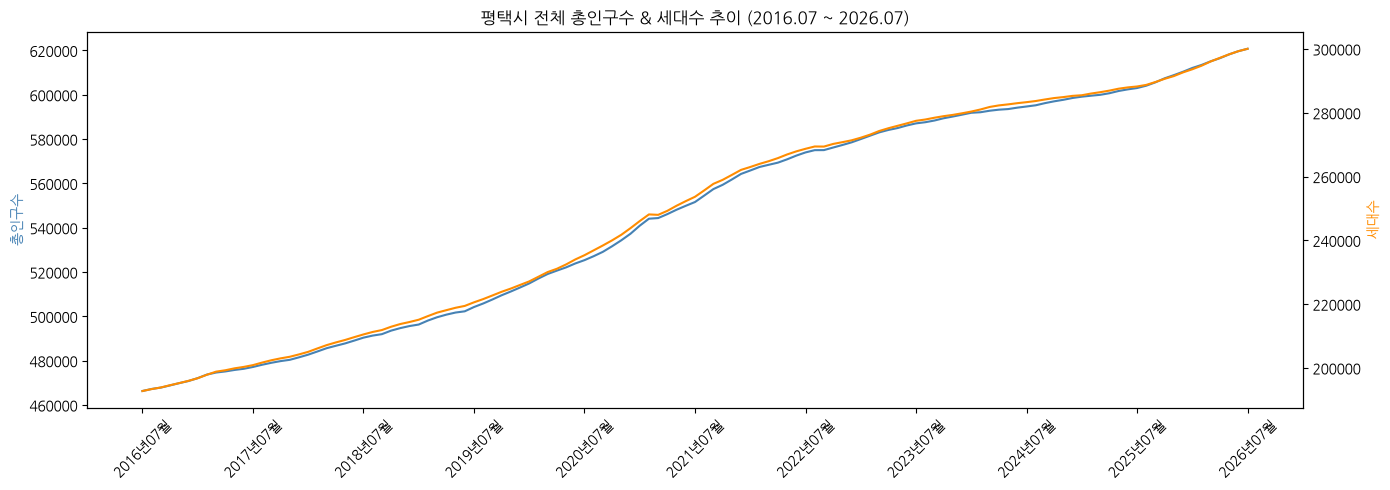

In [32]:
# 평택시 전체 총인구수/세대수 10년 추이

pop_cols = [c for c in pop_2016_2026.columns if '총인구수' in c]
household_cols = [c for c in pop_2016_2026.columns if c.endswith('_세대수')]

city_pop_series = pop_city_total[pop_cols].iloc[0]
city_household_series = pop_city_total[household_cols].iloc[0]

x_labels = [c.replace('_총인구수', '') for c in pop_cols]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(x_labels, city_pop_series.values, color='steelblue', label='총인구수')
ax1.set_ylabel('총인구수', color='steelblue')
ax1.set_xticks(x_labels[::12])  # 1년 단위로만 라벨 표시
ax1.set_xticklabels(x_labels[::12], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x_labels, city_household_series.values, color='darkorange', label='세대수')
ax2.set_ylabel('세대수', color='darkorange')

plt.title('평택시 전체 총인구수 & 세대수 추이 (2016.07 ~ 2026.07)')
fig.tight_layout()
plt.show()

> **읽는 법**: 총인구수보다 세대수가 더 가파르게 증가하고 있다면, '가구 분화(1인 가구 증가)'가 진행 중이라는 뜻입니다. 세대당 인구(다음 셀)로 바로 확인합니다.

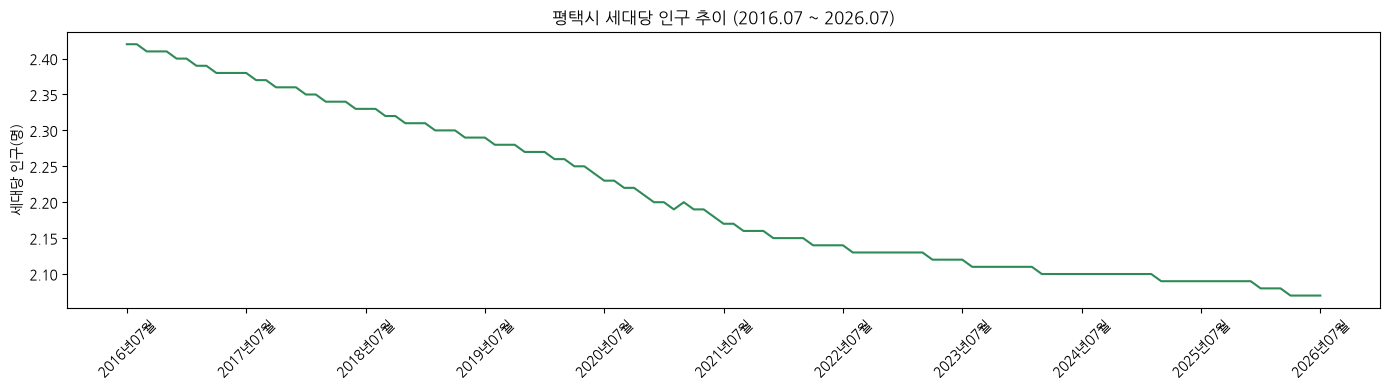

In [33]:
# 세대당 인구(가구 규모) 추이 — 값이 낮아질수록 1인/2인 가구 비중이 늘고 있다는 의미

household_size_cols = [c for c in pop_2016_2026.columns if '세대당 인구' in c]
city_household_size = pop_city_total[household_size_cols].iloc[0]

plt.figure(figsize=(14, 4))
plt.plot(x_labels, city_household_size.values, color='seagreen')
plt.xticks(x_labels[::12], rotation=45)
plt.title('평택시 세대당 인구 추이 (2016.07 ~ 2026.07)')
plt.ylabel('세대당 인구(명)')
plt.tight_layout()
plt.show()

## EDA 2: 동별 최신 인구 순위 & 10년 증감률

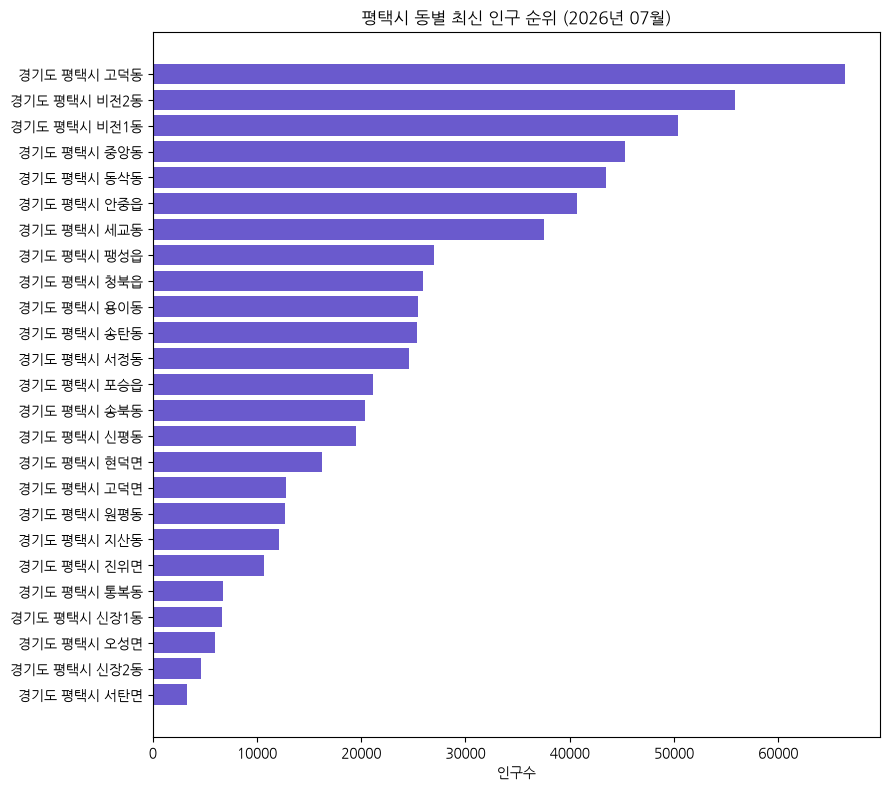

In [34]:
# 동별 최신 인구 순위 (2026년07월 기준)

latest_pop_col = pop_cols[-1]
rank_df = pop_dong_only[['행정구역명', latest_pop_col]].rename(columns={latest_pop_col: '최신인구'})
rank_df = rank_df.sort_values('최신인구', ascending=False)

plt.figure(figsize=(9, 8))
plt.barh(rank_df['행정구역명'], rank_df['최신인구'], color='slateblue')
plt.gca().invert_yaxis()
plt.title('평택시 동별 최신 인구 순위 (2026년 07월)')
plt.xlabel('인구수')
plt.tight_layout()
plt.show()

In [35]:
# 10년(또는 데이터 존재 구간) 증감률 계산
# - 신설동(고덕동/동삭동/용이동)은 초기 결측/0 구간이 있어서, '실제 데이터가 있는 첫 시점' 대비 증감률로 계산

def growth_rate(row):
    series = row[pop_cols]
    valid = series[(series.notna()) & (series > 0)]
    if len(valid) < 2:
        return None
    first_val = valid.iloc[0]
    last_val = valid.iloc[-1]
    return round((last_val - first_val) / first_val * 100, 1)

growth_df = pop_dong_only[['행정구역명'] + pop_cols].copy()
growth_df['최신인구'] = growth_df[latest_pop_col]
growth_df['증감률(%)'] = growth_df.apply(growth_rate, axis=1)
growth_df = growth_df[['행정구역명', '최신인구', '증감률(%)']].sort_values('증감률(%)', ascending=False)

growth_df

,행정구역명,최신인구,증감률(%)
1,경기도 평택시 고덕동,66446,231.7
25,경기도 평택시 현덕면,16271,164.2
8,경기도 평택시 세교동,37508,66.5
10,경기도 평택시 송탄동,25363,59.8
22,경기도 평택시 통복동,6768,47.5
4,경기도 평택시 비전1동,50428,16.9
3,경기도 평택시 동삭동,43468,15.8
21,경기도 평택시 청북읍,25923,11.4
19,경기도 평택시 지산동,12154,9.1
2,경기도 평택시 고덕면,12771,7.6


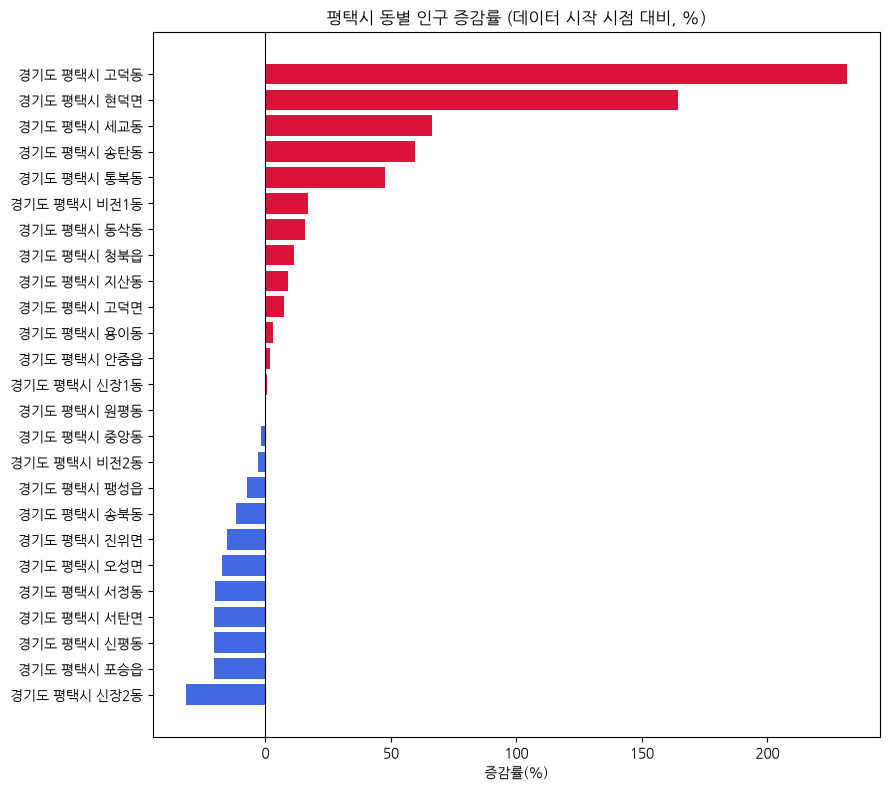

In [36]:
# 증감률 시각화 (증가는 빨강, 감소는 파랑)

colors = ['crimson' if v >= 0 else 'royalblue' for v in growth_df['증감률(%)']]

plt.figure(figsize=(9, 8))
plt.barh(growth_df['행정구역명'], growth_df['증감률(%)'], color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.title('평택시 동별 인구 증감률 (데이터 시작 시점 대비, %)')
plt.xlabel('증감률(%)')
plt.tight_layout()
plt.show()

> 고덕동(+232%), 현덕면(+164%), 세교동(+67%), 송탄동(+60%)처럼 급성장한 지역과, 신장2동(-32%)·포승읍(-21%)처럼 인구가 줄어든 지역이 뚜렷하게 갈립니다. 성장 지역은 인프라 확충, 감소 지역은 원인 파악(고령화? 산업 쇠퇴?)이 필요한 정책 후보입니다.

## EDA 3: 성비 분석

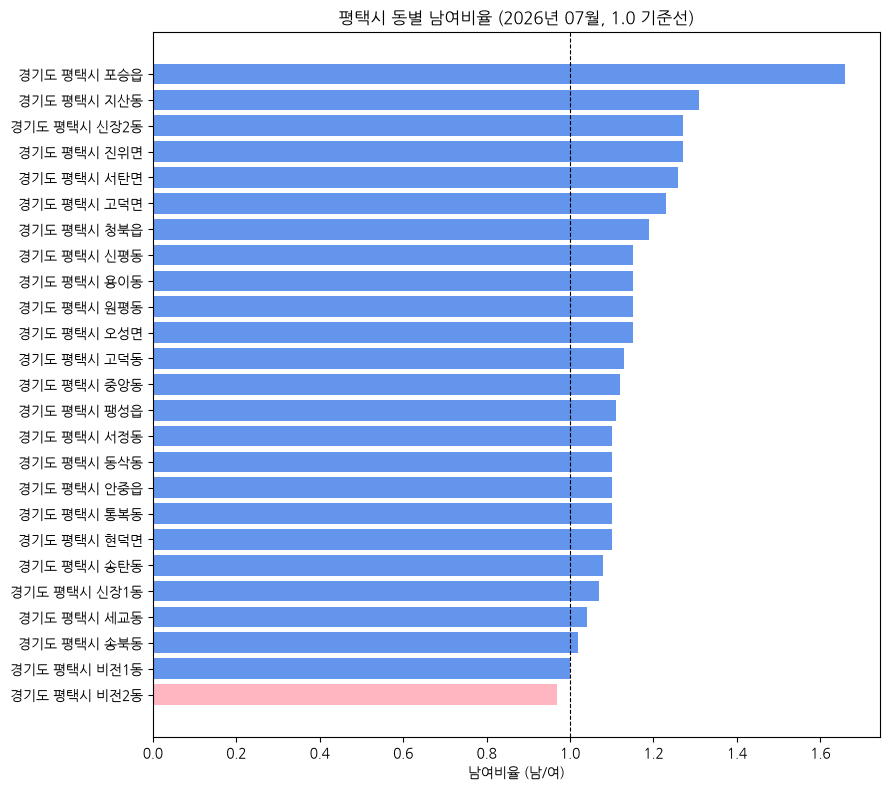

In [37]:
# 동별 최신 남여비율 (1.0 초과 = 남초, 1.0 미만 = 여초)

ratio_cols = [c for c in pop_2016_2026.columns if '남여 비율' in c]
latest_ratio_col = ratio_cols[-1]

gender_df = pop_dong_only[['행정구역명', latest_ratio_col]].rename(columns={latest_ratio_col: '남여비율'})
gender_df = gender_df.sort_values('남여비율', ascending=False)

colors = ['cornflowerblue' if v >= 1 else 'lightpink' for v in gender_df['남여비율']]

plt.figure(figsize=(9, 8))
plt.barh(gender_df['행정구역명'], gender_df['남여비율'], color=colors)
plt.gca().invert_yaxis()
plt.axvline(1.0, color='black', linewidth=0.8, linestyle='--')
plt.title('평택시 동별 남여비율 (2026년 07월, 1.0 기준선)')
plt.xlabel('남여비율 (남/여)')
plt.tight_layout()
plt.show()

> 남여비율이 눈에 띄게 높은 지역(1.2 이상)은 산업단지·군부대 등 남성 비중이 높은 시설이 인근에 있을 가능성이 있습니다. 평택은 미군기지·산업단지가 많아 실제로 이런 패턴이 나타날 수 있어요.

## 분석검증: 인구 증감 패턴과 연령 구조를 교차 검증

앞서 따로 살펴본 **① 10년 인구 증감률**과 **② 2026년 상반기 연령 구조**를 하나로 합쳐서,
'인구가 느는 동네가 정말로 젊은 동네인지', '인구가 주는 동네가 정말로 고령화된 동네인지'를 교차 검증합니다.

증감률과 고령인구비율 각각의 중앙값을 기준으로 4개 유형으로 나눕니다:
- **성장+젊음**: 인구 증가 + 고령비율 낮음 → 인프라 확충 시급
- **성장+고령화**: 인구는 늘지만 고령비율도 높음 → 혼재형, 유입 인구 성격 추가 확인 필요
- **감소+고령화**: 인구 감소 + 고령비율 높음 → 쇠퇴 위험, 고령 돌봄 정책 시급
- **감소+젊음**: 인구는 줄지만 고령비율은 낮음 → 원인이 다를 수 있음(재개발/이주 등), 별도 확인 필요

In [38]:
# growth_df(증감률) + age_latest(연령구조) 병합

quad_df = growth_df.merge(
    age_latest[['행정구역명', '고령인구비율(%)', '유소년비율(%)']],
    on='행정구역명', how='left'
)
quad_df = quad_df[quad_df['행정구역명'] != '경기도 평택시']

growth_med = quad_df['증감률(%)'].median()
age_med = quad_df['고령인구비율(%)'].median()

def quadrant(row):
    is_growing = row['증감률(%)'] >= growth_med
    is_aged = row['고령인구비율(%)'] >= age_med
    if is_growing and not is_aged:
        return '성장+젊음 (인프라 확충형)'
    elif is_growing and is_aged:
        return '성장+고령화 (혼재형)'
    elif not is_growing and is_aged:
        return '감소+고령화 (쇠퇴 위험형)'
    else:
        return '감소+젊음 (관찰필요형)'

quad_df['유형'] = quad_df.apply(quadrant, axis=1)
quad_df.sort_values('증감률(%)', ascending=False)

,행정구역명,최신인구,증감률(%),고령인구비율(%),유소년비율(%),유형
0,경기도 평택시 고덕동,66446,231.7,4.8,15.8,성장+젊음 (인프라 확충형)
1,경기도 평택시 현덕면,16271,164.2,17.8,8.7,성장+젊음 (인프라 확충형)
2,경기도 평택시 세교동,37508,66.5,13.8,8.9,성장+젊음 (인프라 확충형)
3,경기도 평택시 송탄동,25363,59.8,11.7,10.6,성장+젊음 (인프라 확충형)
4,경기도 평택시 통복동,6768,47.5,19.7,8.2,성장+고령화 (혼재형)
5,경기도 평택시 비전1동,50428,16.9,14.0,6.8,성장+젊음 (인프라 확충형)
6,경기도 평택시 동삭동,43468,15.8,7.2,12.0,성장+젊음 (인프라 확충형)
7,경기도 평택시 청북읍,25923,11.4,13.9,7.9,성장+젊음 (인프라 확충형)
8,경기도 평택시 지산동,12154,9.1,16.5,2.8,성장+젊음 (인프라 확충형)
9,경기도 평택시 고덕면,12771,7.6,20.5,5.6,성장+고령화 (혼재형)


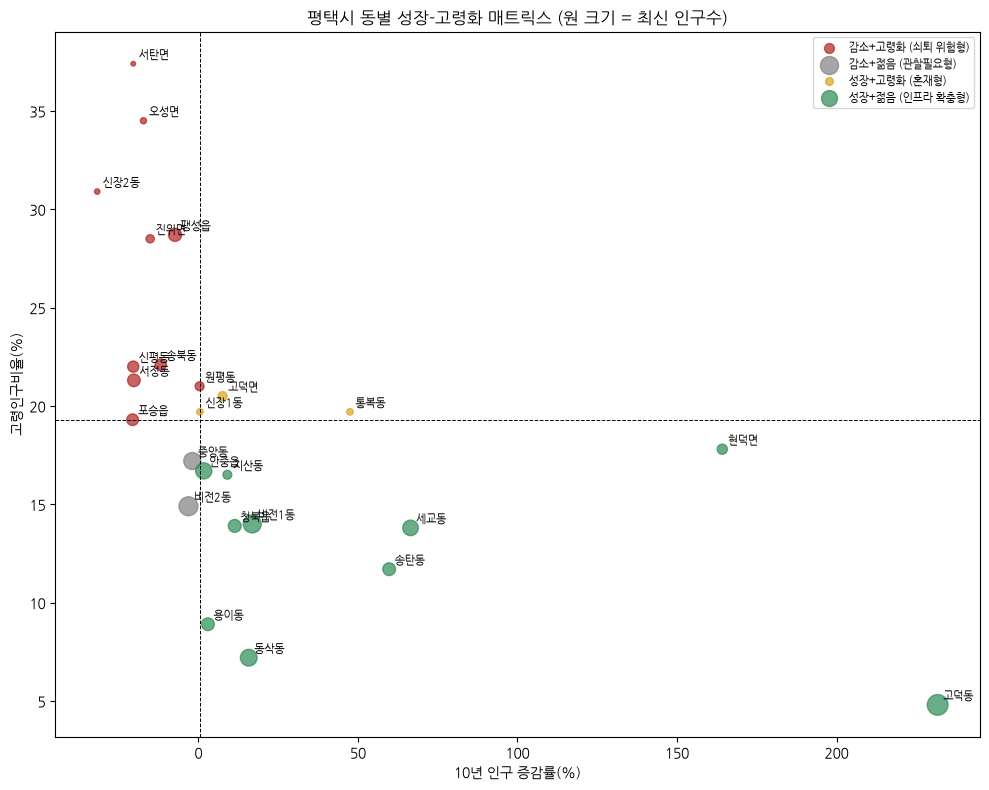

In [39]:
# 4분면 산점도로 시각화

color_map = {
    '성장+젊음 (인프라 확충형)': 'seagreen',
    '성장+고령화 (혼재형)': 'goldenrod',
    '감소+고령화 (쇠퇴 위험형)': 'firebrick',
    '감소+젊음 (관찰필요형)': 'gray'
}

plt.figure(figsize=(10, 8))
for 유형, group in quad_df.groupby('유형'):
    plt.scatter(group['증감률(%)'], group['고령인구비율(%)'],
                s=group['최신인구']/300, alpha=0.7,
                color=color_map[유형], label=유형)
    for _, row in group.iterrows():
        plt.annotate(row['행정구역명'].replace('경기도 평택시 ', ''),
                     (row['증감률(%)'], row['고령인구비율(%)']),
                     fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.axvline(growth_med, color='black', linestyle='--', linewidth=0.7)
plt.axhline(age_med, color='black', linestyle='--', linewidth=0.7)
plt.xlabel('10년 인구 증감률(%)')
plt.ylabel('고령인구비율(%)')
plt.title('평택시 동별 성장-고령화 매트릭스 (원 크기 = 최신 인구수)')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

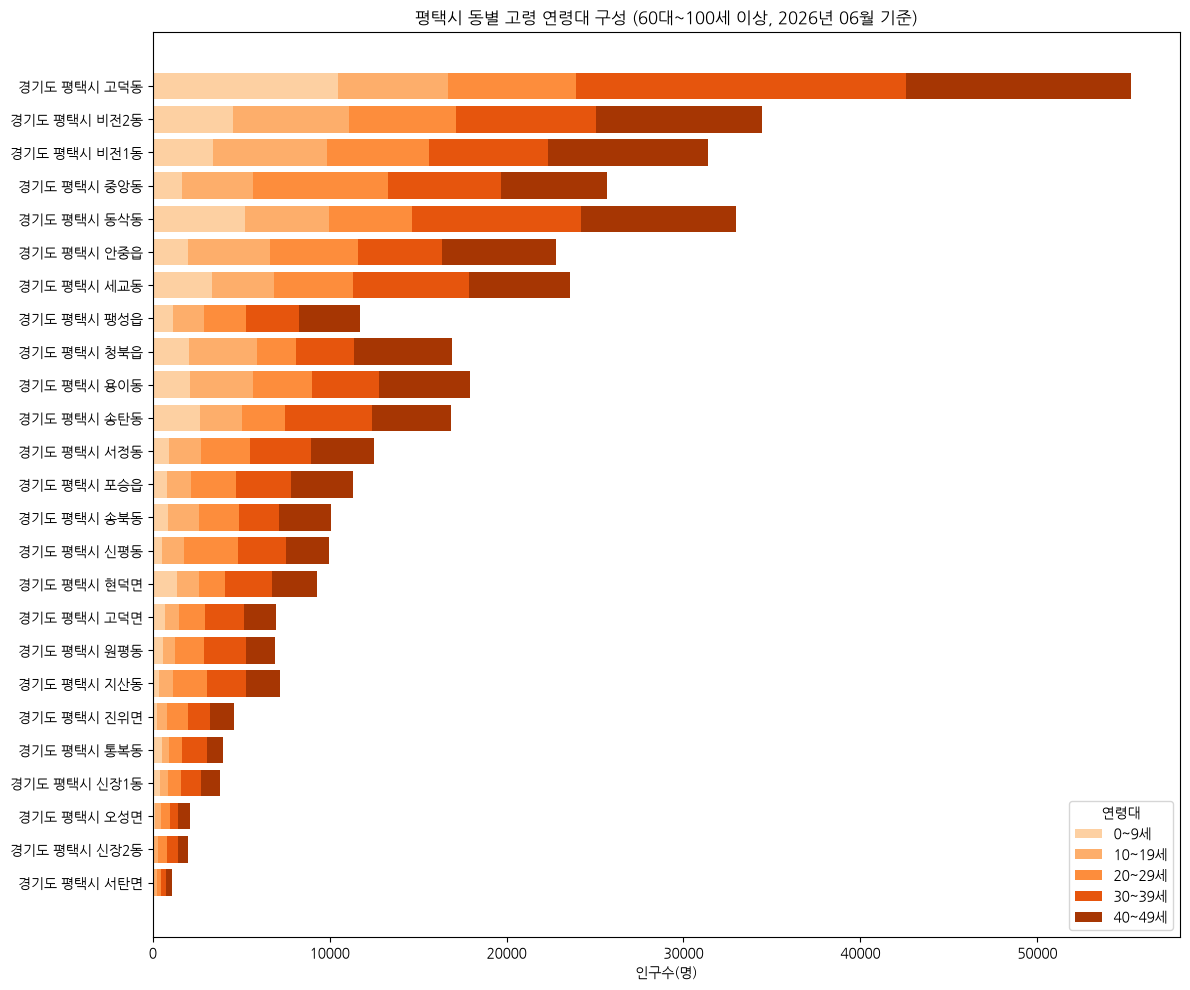

In [42]:
# 동별 고령 연령대(60대~100세+) 구성을 누적 막대그래프로 시각화
# 이미 정의된 age_latest, age_bands 변수를 그대로 활용

elderly_df = age_latest[age_latest['행정구역명'] != '경기도 평택시'].copy()
elderly_df['고령인구합계'] = elderly_df[age_bands].sum(axis=1)
elderly_df = elderly_df.sort_values('고령인구합계', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
bottom = pd.Series([0] * len(elderly_df), index=elderly_df.index)
colors = ['#fdd0a2', '#fdae6b', '#fd8d3c', '#e6550d', '#a63603']  # 연한 주황 -> 진한 주황(고연령일수록 진하게)

for band, color in zip(age_bands, colors):
    ax.barh(elderly_df['행정구역명'], elderly_df[band], left=bottom, color=color, label=band)
    bottom += elderly_df[band]

ax.invert_yaxis()  # 인구 많은 동이 위로 오도록
ax.set_xlabel('인구수(명)')
ax.set_title('평택시 동별 고령 연령대 구성 (60대~100세 이상, 2026년 06월 기준)')
ax.legend(title='연령대', loc='lower right')
plt.tight_layout()
plt.show()

In [40]:
quad_df['유형'].value_counts()

유형
성장+젊음 (인프라 확충형)    10
감소+고령화 (쇠퇴 위험형)    10
성장+고령화 (혼재형)        3
감소+젊음 (관찰필요형)       2
Name: count, dtype: int64

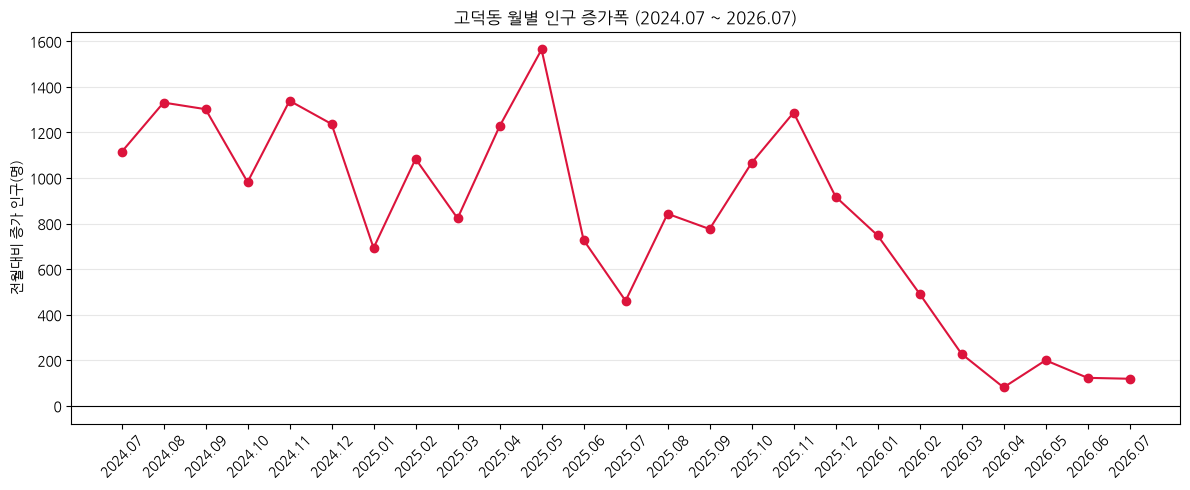

In [41]:
# 고덕동 최근 24개월 전월대비 인구 증가폭

godeok = pop_2016_2026[pop_2016_2026['행정구역명'] == '경기도 평택시 고덕동']

pop_series = godeok[pop_cols].iloc[0]
monthly_diff = pop_series.diff().tail(25)  # 최근 25개월(첫 diff 제외하면 24개월 증가폭)

x_labels = [c.replace('_총인구수', '').replace('년', '.').replace('월', '') for c in monthly_diff.index]

plt.figure(figsize=(12, 5))
plt.plot(x_labels, monthly_diff.values, marker='o', color='crimson')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('고덕동 월별 인구 증가폭 (2024.07 ~ 2026.07)')
plt.ylabel('전월대비 증가 인구(명)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 검증 결과

25개 동 중 **10곳은 '성장+젊음'**, **10곳은 '감소+고령화'**로 정확히 양극화되어 있습니다.
이는 단순 우연이 아니라, **택지개발이 진행 중인 신도심(성장)**과 **개발이 끝났거나 원도심/농촌인 지역(쇠퇴)**
이 뚜렷하게 갈리는 구조적 패턴임을 뒷받침합니다.

- **성장+젊음 10곳**: 고덕동(+232%), 현덕면(+164%), 세교동(+67%), 송탄동(+60%), 비전1동, 동삭동, 청북읍, 지산동, 용이동, 안중읍
- **감소+고령화 10곳**: 신장2동(-32%), 포승읍(-21%), 신평동(-20%), 서탄면(-20%), 서정동(-20%), 오성면(-17%), 진위면(-15%), 송북동(-12%), 팽성읍(-7%), 원평동(0.4%)
- 나머지 5곳(통복동, 고덕면, 신장1동, 중앙동, 비전2동)은 혼재형/관찰필요형으로, 추가 요인(재개발, 상권 변화 등) 확인이 필요합니다.

## 해석 및 의사결정: 구청/시청 행정정책 제안 (데이터 분석 + 외부 자료조사 종합)

앞선 EDA·분석검증 결과(데이터)와, 평택시·경기도·정부의 실제 정책 자료조사(외부 근거)를 종합하여
문제정의에서 제기한 4가지 질문에 답하는 형태로 정책 제안을 정리합니다.

---

### 제안 1. 신도심(성장+젊음 지역) — 보육·교육 인프라 확충 가속화

**데이터 근거**: 고덕동(+232%), 세교동(+67%), 송탄동(+60%), 동삭동(+16%) 등 신도심 10곳은 10년간 인구가 급증했고,
유소년비율(8~16%)이 평택시 평균(7.5%)보다 뚜렷하게 높습니다.

**외부 자료 근거**: 이 예측은 실제 현장 문제로 이미 확인되고 있습니다.
- 2026년 4월 기준 평택시 국공립어린이집 정원은 6,001명인데 현원은 4,819명에 그치고, 대기자는 8,720명에 달합니다(연령별·지역별 수요·공급 불일치).
- 고덕국제화계획지구는 학생 수 급증에 따라 '고덕8초'(41학급 규모)가 2028년 9월 개교를 목표로 신설 확정되었습니다.
- 고덕신도시 에듀타운 구역에는 유치원~고등학교 13개교 신설이 계획되어 있습니다.

**제안**: 
- 국공립어린이집을 '정원 총량' 기준이 아니라 **단지별·연령별 실제 거주 아동 수** 기준으로 재배치
- 학교 신설이 2028년 개교로 예정되어 있어 향후 2년간 '공백기' 대응책(임시 교실 증축, 통학 지원) 필요
- 세교동·송탄동처럼 이미 60% 넘게 성장했지만 상대적으로 주목도가 낮은 지역도 유소년비율을 모니터링해 2차 확충 대상으로 선제 검토

---

### 제안 2. 원도심·면 지역(감소+고령화) — 고령친화 정책 및 인구활력 대응

**데이터 근거**: 서탄면(고령 37%), 오성면(35%), 신장2동(31%)은 고령비율이 매우 높고 동시에 10년간 인구가 15~32% 감소했습니다.

**외부 자료 근거**:
- 평택시는 이미 중소벤처기업부 공모사업에 선정되어 AI 기반 노인 돌봄 안전망을 평택시립노인전문요양원에 시범 도입 중입니다(야간 인력 부족·고령화 대응 목적).
- 2026년 3월부터 경기도 31개 시·군에서 '돌봄통합지원법'에 따른 통합돌봄이 시행되어, 읍면동 신청 시 보건의료·건강관리·장기요양·일상돌봄을 통합 제공합니다.
- 정부는 「인구감소지역 지원 특별법」을 통해 연평균인구증감률·고령화비율·유소년비율 등 8개 지표로 '인구감소지수'를 산정해 지역별 맞춤 지원을 제공합니다 — 이는 본 분석의 '증감률×고령비율 매트릭스'와 사실상 동일한 접근입니다.

**제안**:
- 서탄면·오성면·신장2동을 시 자체 '읍면동 단위 인구활력 관리 대상'으로 지정하고, 경기도 통합돌봄 서비스 신청률을 이 지역부터 우선 홍보·지원
- 평택시 AI 돌봄 시범사업의 2차 확대 대상지로 고령비율 상위 지역(서탄면·오성면 등)을 우선 검토 건의
- 시 전체는 인구증가 추세라 국가 인구감소지역 지정 대상은 아니지만, 읍면동 단위로는 인구감소지역 지정 기준에 근접한 곳이 있어 시 차원의 별도 지원 예산 편성 검토

---

### 제안 3. 혼재형 지역(통복동, 고덕면, 신장1동) — 모니터링 대상 지정

**데이터 근거**: 인구는 소폭 증가했지만 고령비율도 평균 이상인 지역입니다.

**제안**: 재개발/재건축 진행 여부, 유입 인구의 연령대(신혼부부 vs 은퇴자 귀촌)를 추가 확인하여 정책 방향을
성장형/고령형 중 하나로 명확히 잡을 필요가 있습니다.

---

### 종합 결론

데이터 분석(내부)과 실제 정책·언론 자료(외부)가 서로 다른 경로로 도출되었음에도 **같은 결론**을 가리킵니다:
평택시는 신도심과 원도심/면 지역 사이의 양극화가 이미 진행 중이며, 각 지역에 필요한 정책의 성격이 명확히 다릅니다.
따라서 시 전체를 대상으로 한 획일적 정책보다는, **본 분석에서 제시한 4분면 유형(성장+젊음 / 성장+고령화 / 감소+고령화 / 감소+젊음)에
따라 예산과 정책을 차등 배분하는 것**이 더 효과적인 접근이 될 수 있습니다.

### 남은 한계 및 추가 분석 필요 사항
- 연령 데이터가 2026년 상반기 6개월치뿐이라, 고령화 추이를 시계열로는 확인하지 못함 → 과거 연령별 데이터 확보 시 추가 분석 필요
- 인구 감소의 원인(전출/사망/출생 감소)이 데이터에 분리되어 있지 않아, 정확한 원인 진단을 위해선 전입·전출 통계 등 보완 데이터 필요
- 국공립어린이집 대기자 수(8,720명) 등 외부 자료는 시 전체 통계이므로, 동별로 세분화된 수급 데이터를 추가로 확보하면 더 정밀한 우선순위 산정 가능

### 참고자료 (외부 자료조사 출처)


- [평택시사회복지협의회 - 2026년 노인맞춤돌봄서비스 사업](https://ptcsw.or.kr/bbs/board.php?bo_table=p_data&wr_id=24&page=1)
- [세계환경신문 - 평택시, 'AI 기반 노인요양원 돌봄' 구축](https://www.e-newsp.com/news/article.html?no=90147)
- [평택시사회복지협의회 - 2026년 더 좋아지는 경기도 복지·보건 정책](https://www.ptcsw.or.kr/bbs/board.php?bo_table=news&wr_id=521&sca=%EC%82%AC%ED%9A%8C%EB%B3%B5%EC%A7%80%EB%89%B4%EC%8A%A4&page=1)
- [B tv news - 평택 고덕, 초등학교 추가 신설 2028년 개교](https://news.skbroadband.com/news/articleView.html?idxno=206721)
- [평택시민신문 - 고덕지구 8번째 초등학교 신설 확정](https://www.pttimes.com/news/articleView.html?idxno=76257)
- [이투뉴스 - 고덕신도시 에듀타운 교육특화구역](http://www.e2news.com/news/articleView.html?idxno=240333)
- [뉴스핌 - '평택을' 조국 후보, 고덕 보육·돌봄 체계 재설계 발언 (국공립어린이집 수급 통계)](https://www.newspim.com/news/view/20260522000192)
- [나무위키 - 평택시 (동별 인구 현황)](https://namu.wiki/w/%ED%8F%89%ED%83%9D%EC%8B%9C)
- [행정안전부 - 인구감소지역 지원 특별법](https://www.mois.go.kr/frt/sub/a06/b06/populationDeclineLaw/screen.do)
- [나비스(NABIS) 균형발전종합정보시스템 - 인구감소대응](https://www.nabis.go.kr/contentsDetailView.do?menucd=258&menuFlag=Y)

- [마을 활동가](https://www.nspna.com/country/?mode=view&newsid=817647)

> 위 자료들은 2026년 8월 기준 검색된 정보이며, 정책은 계속 갱신될 수 있으므로 실제 제안 시 최신 공고를 다시 확인하는 것을 권장합니다.

# 아이디어

### "평택 슬로타운" — 원도심을 유치 대상으로 재브랜딩
서울/경기 남부 은퇴 예정자를 대상으로 "평택 슬로타운" 정착 지원 패키지(주거 리모델링 보조금 + 초기 정착 컨설팅)를 만들어, 기존 주민 복지가 아니라 신규 유입으로 인구 감소를 막습니다.


## "휴먼 라이브러리 순회 학교" — 원도심 어르신을 신도심 아이들의 교육자원으로
역할이 있는 노후

서탄면·오성면 어르신들은 평택 농업사, 옛 평택 이야기, 전통 기술(농사·손기술) 같은 "살아있는 지역 지식"을 갖고 있어요.
고덕동·동삭동 신도심 초등학교(고덕8초 등)의 지역화 교육과정에 "찾아가는 어르신 강사" 프로그램을 정식 편성 — 어르신에게는 활동비+사회참여, 학교에는 콘텐츠, 아이들에겐 지역정체성 교육을 제공합니다.

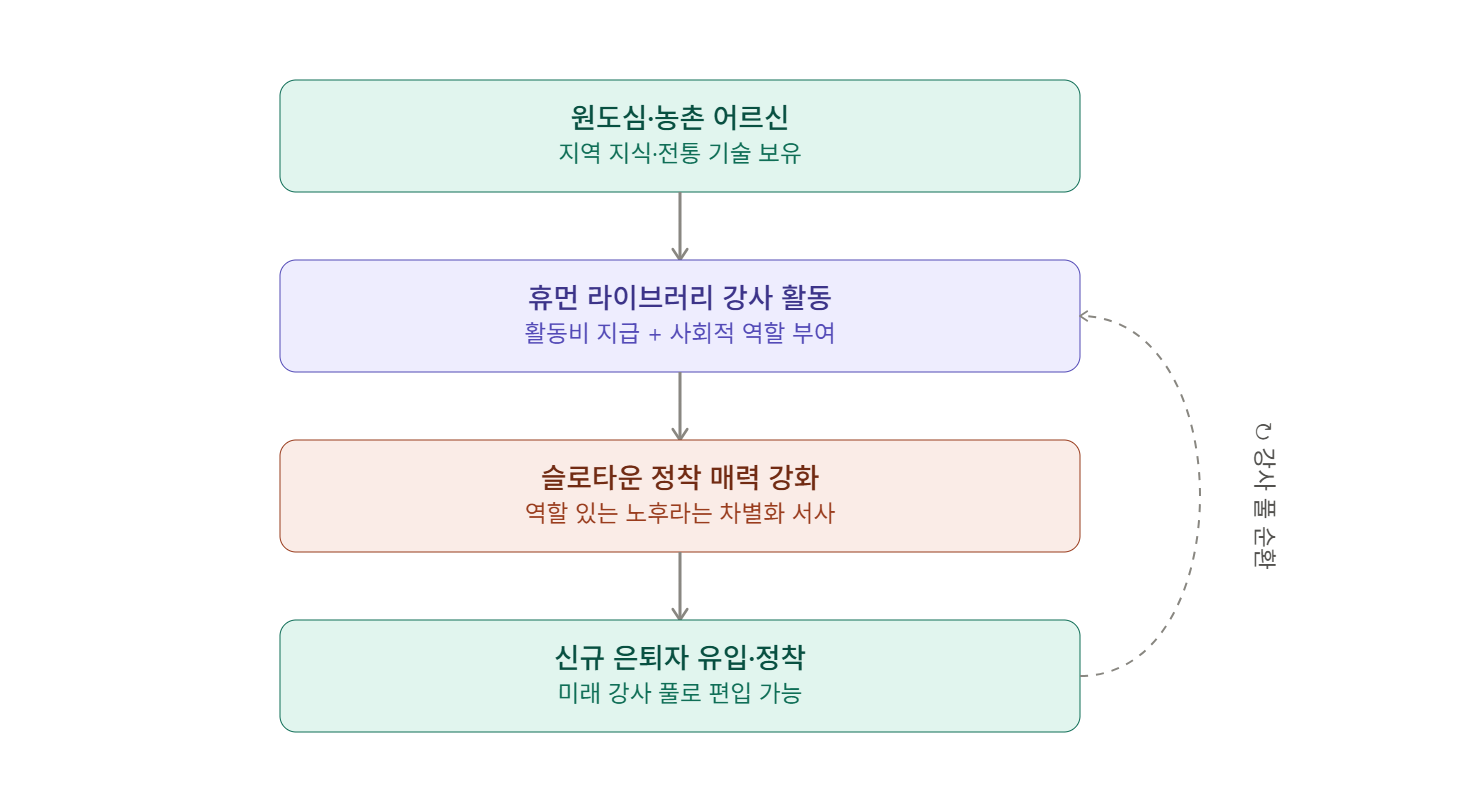

배경목적-> 분석 -> 분석중에서 어떠한걸 포거싱했다 -> 그래서 이부분의 결과로 이러한 정책을 제안하면 좋겠다. 순으로 발표자료 만들기